<a href="https://colab.research.google.com/github/muskan2109/FML_Practicals/blob/main/TASK_1_EE510.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np




In [10]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import  train_test_split

**Read Data**

In [11]:
df=pd.read_csv('/content/retail_sales_dataset.csv')

**Head Of Data**

In [12]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


**Check Null Value**

In [13]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


**PairPlot** *italicised text*

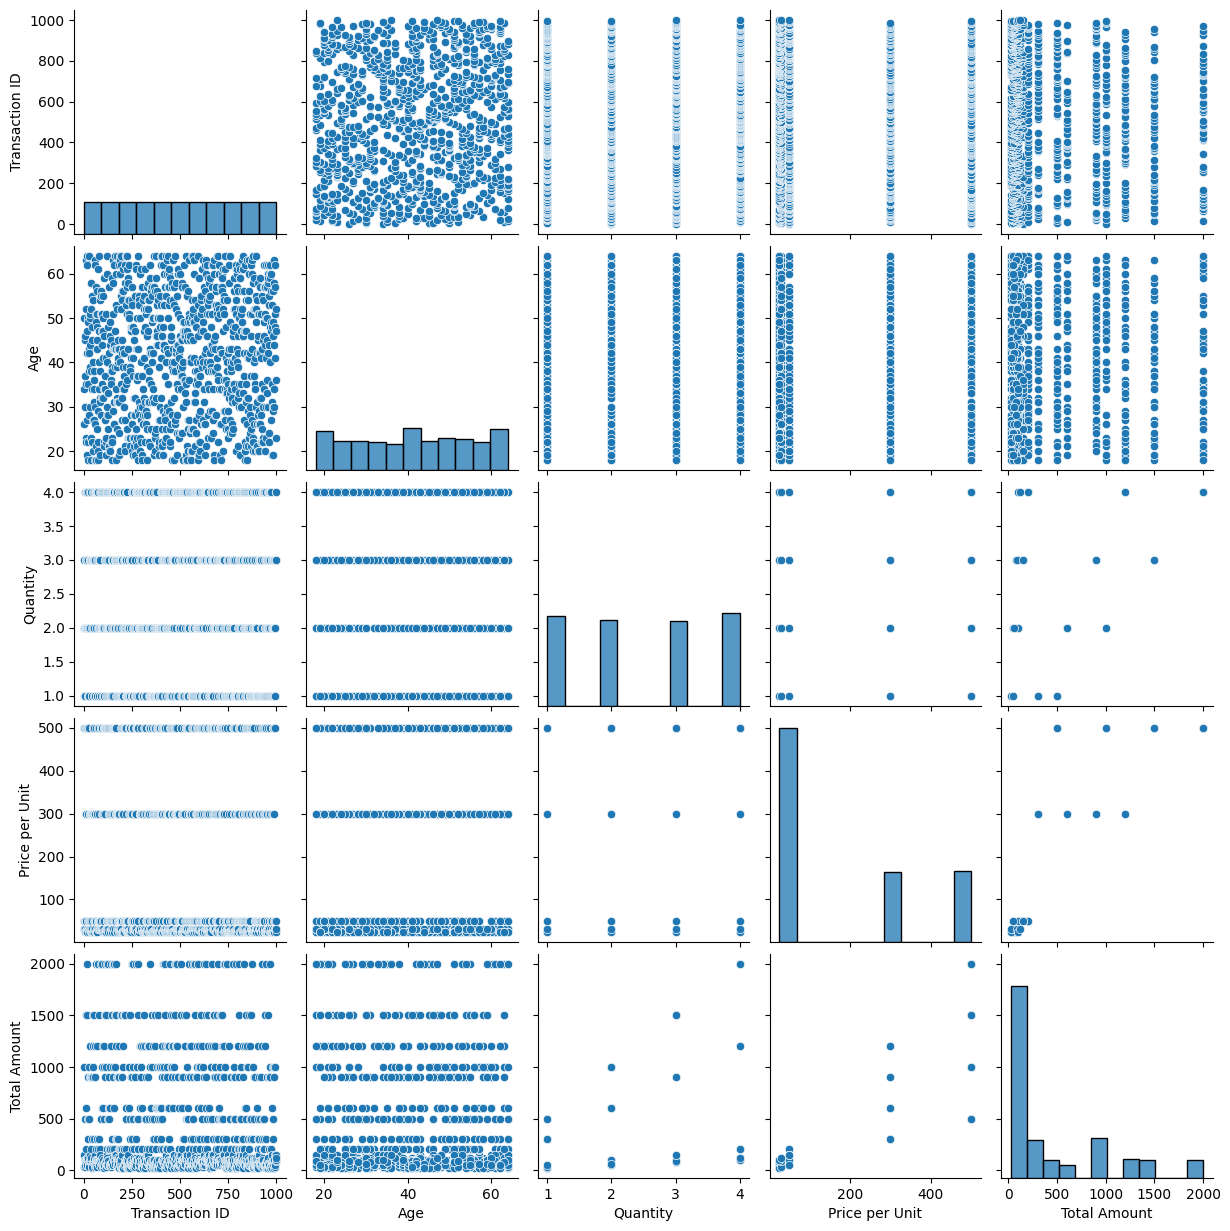

In [14]:
sns.pairplot(data=df)

**1. Univariate analysis Categorical**

In [15]:
# Pie Chart
# Gender Distribution

df1 = df[['Gender']]

fig = px.pie(
    df1,
    names='Gender',
    title='Gender Distribution'
)

fig.show()

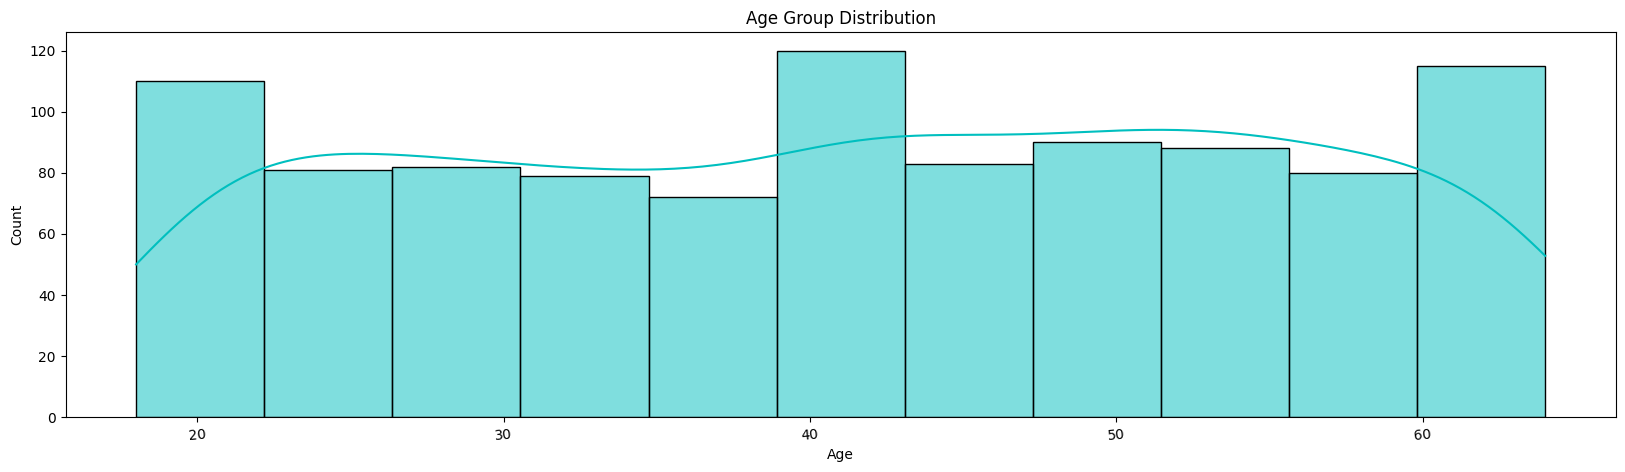

In [ ]:
#Histogram Plot
#Age Group Distribution
plt.figure(figsize=(20,5))
sns.histplot(data=df,
             x=df['Age'].sort_values(),
             kde=True,
             color='c')

plt.title('Age Group Distribution')
plt.xticks(rotation=5)
plt.show()

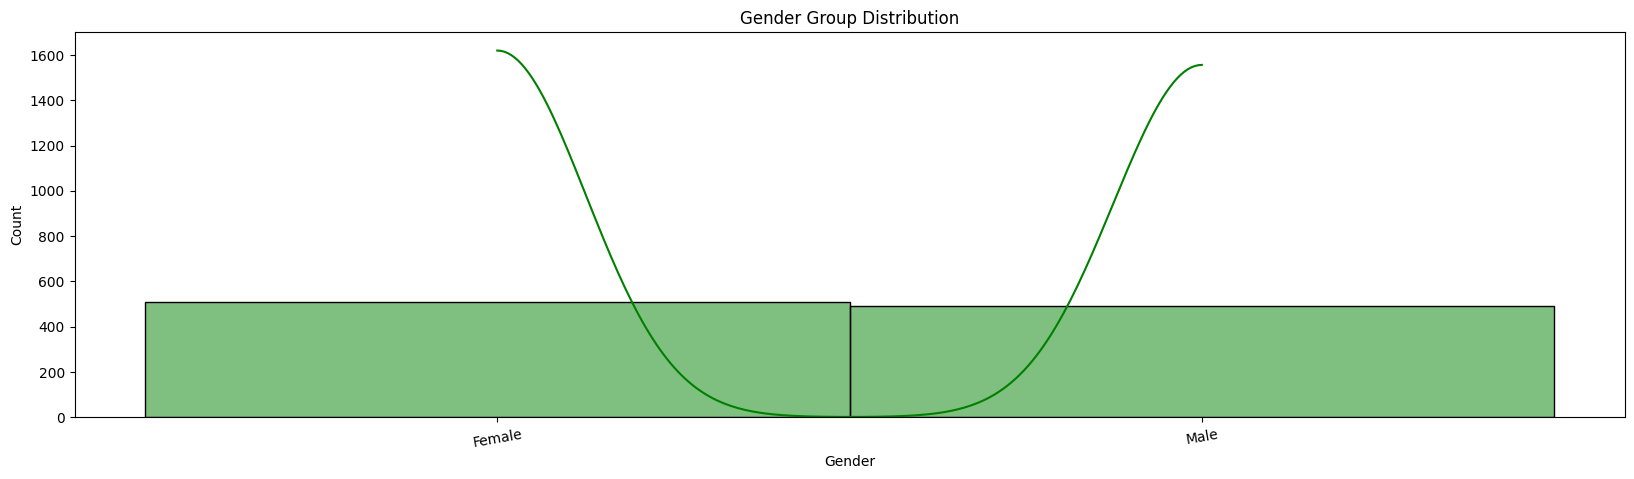

In [ ]:
#Hist plot
#Gender Group Distribution
plt.figure(figsize=(20,5))
sns.histplot(data=df,
             x=df['Gender'].sort_values(),
             kde=True,
             color='g')

plt.title('Gender Group Distribution')
plt.xticks(rotation=10)
plt.show()

In [ ]:
#Violin plot
#Gender & Age Group Distribution
plot = px.violin(x=df['Gender'],
                 y=df['Age'],
                 box=True,
                 points='all')

plot.update_traces(
    box_fillcolor='green',
    opacity=0.5
)

plot.update_layout(
    title='Gender & Age Group Distribution',
    xaxis_title='Gender',
    yaxis_title='Age Group'
)

plot.show()

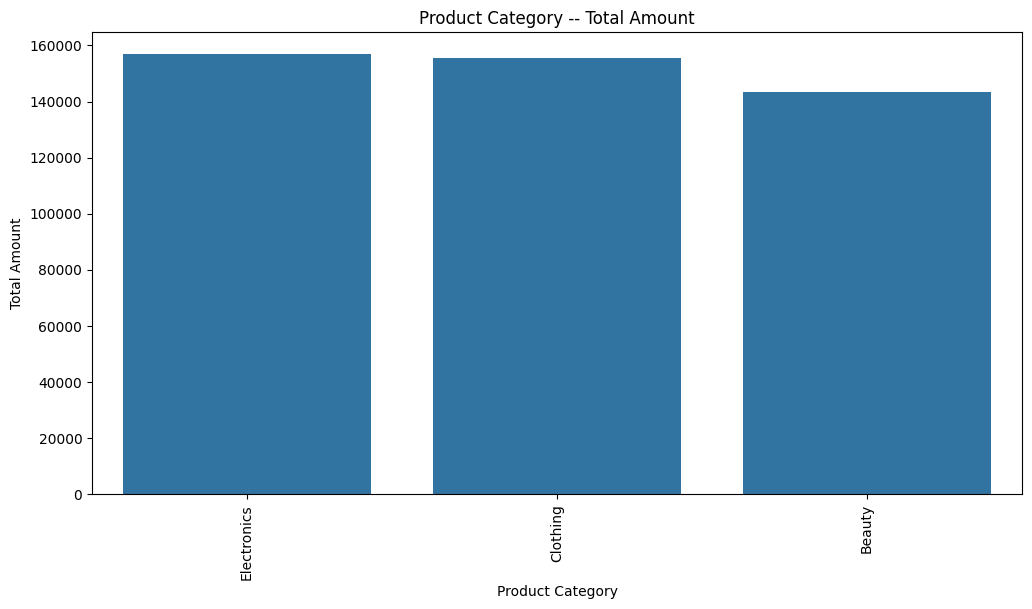

In [ ]:
#Bar Plot
#Gold_item_net_wt_sum
Gold_item_net_wt = df.groupby('Product Category')['Total Amount'].sum().nlargest(40)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=Gold_item_net_wt.index,
    y=Gold_item_net_wt.values
)

plt.xticks(rotation=90)
plt.title("Product Category -- Total Amount")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.show()

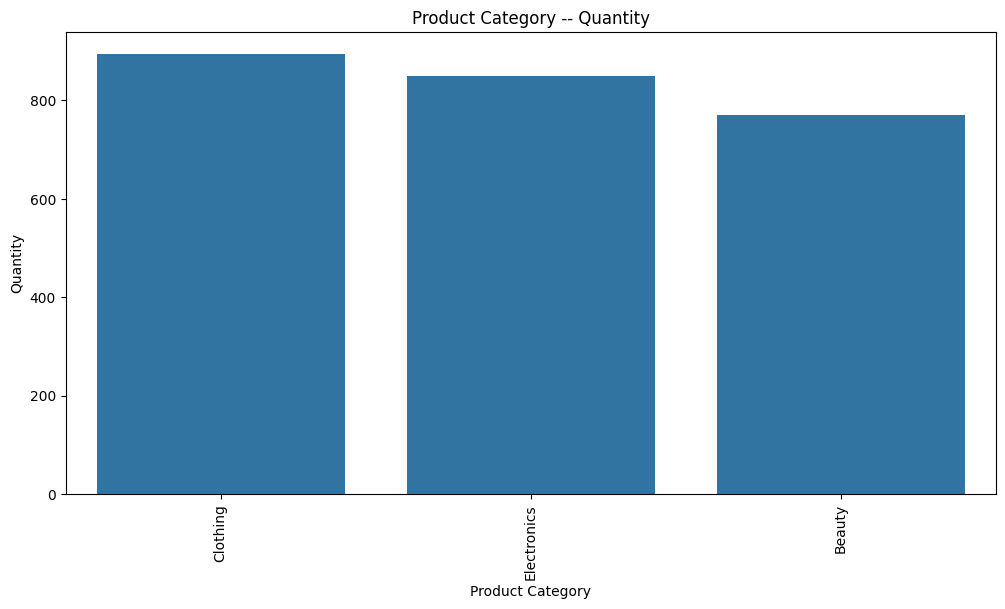

In [ ]:
#Bar Plot
#Gold_item_net_wt_sum
Gold_item_net_wt = df.groupby('Product Category')['Quantity'].sum().nlargest(40)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=Gold_item_net_wt.index,
    y=Gold_item_net_wt.values
)

plt.xticks(rotation=90)
plt.title("Product Category -- Quantity")
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.show()

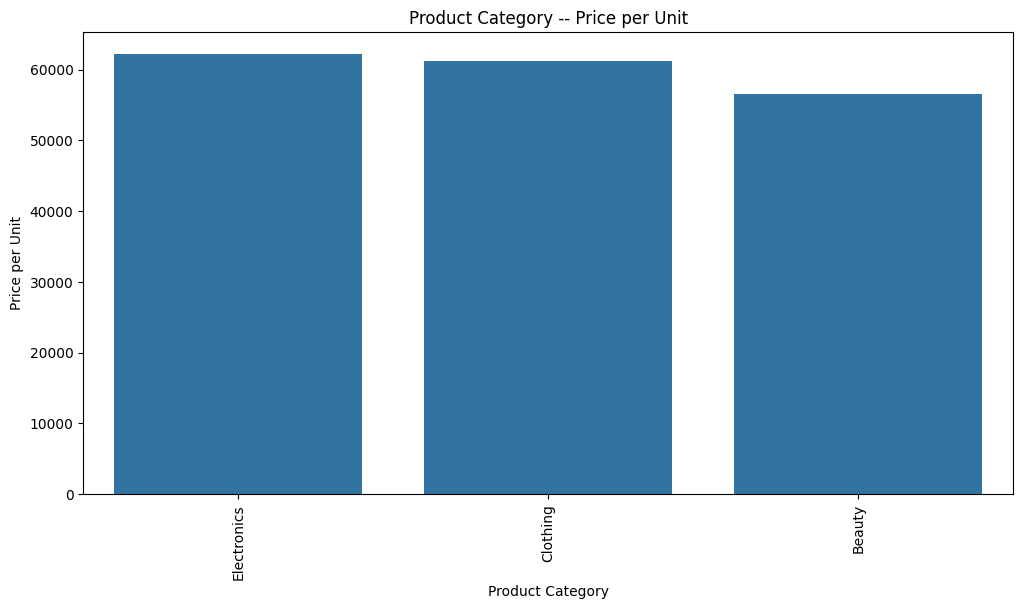

In [ ]:
#Bar Plot
#Gold_item_net_wt_sum
Gold_item_net_wt = df.groupby('Product Category')['Price per Unit'].sum().nlargest(40)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=Gold_item_net_wt.index,
    y=Gold_item_net_wt.values
)

plt.xticks(rotation=90)
plt.title("Product Category -- Price per Unit")
plt.xlabel("Product Category")
plt.ylabel("Price per Unit")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

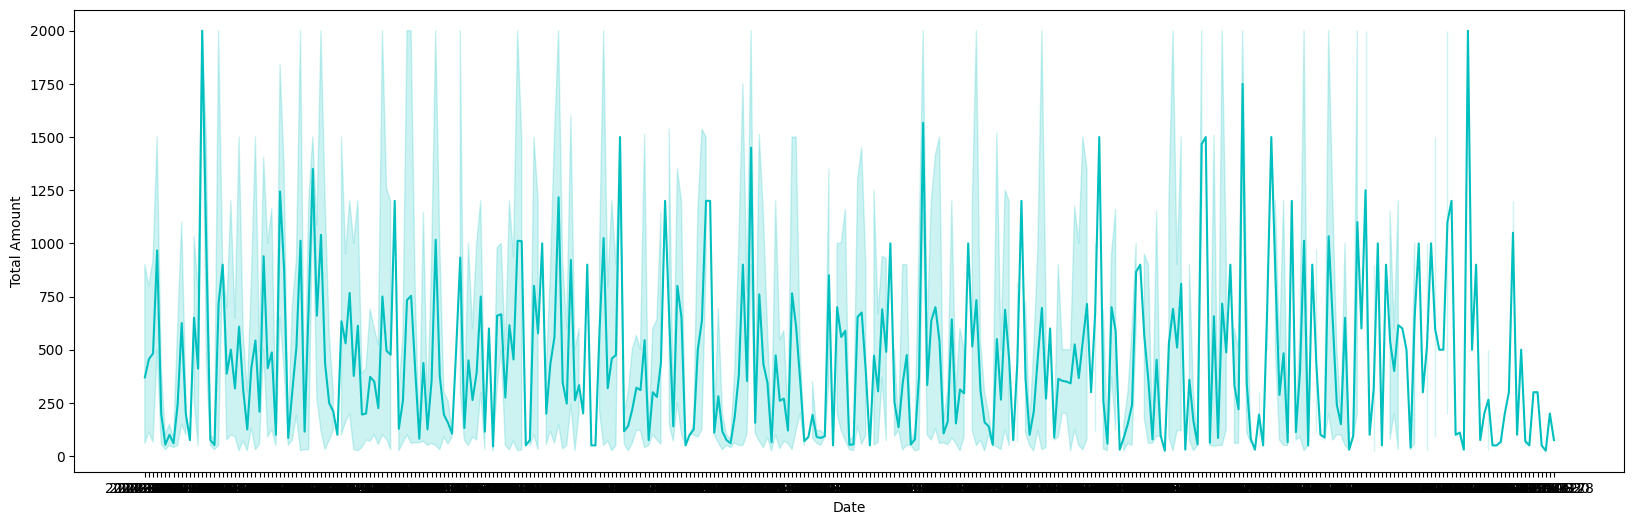

In [ ]:
plt.figure(figsize=(20,6))
sns.lineplot(data=df, x=df['Date'], y=df['Total Amount'], color='c')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

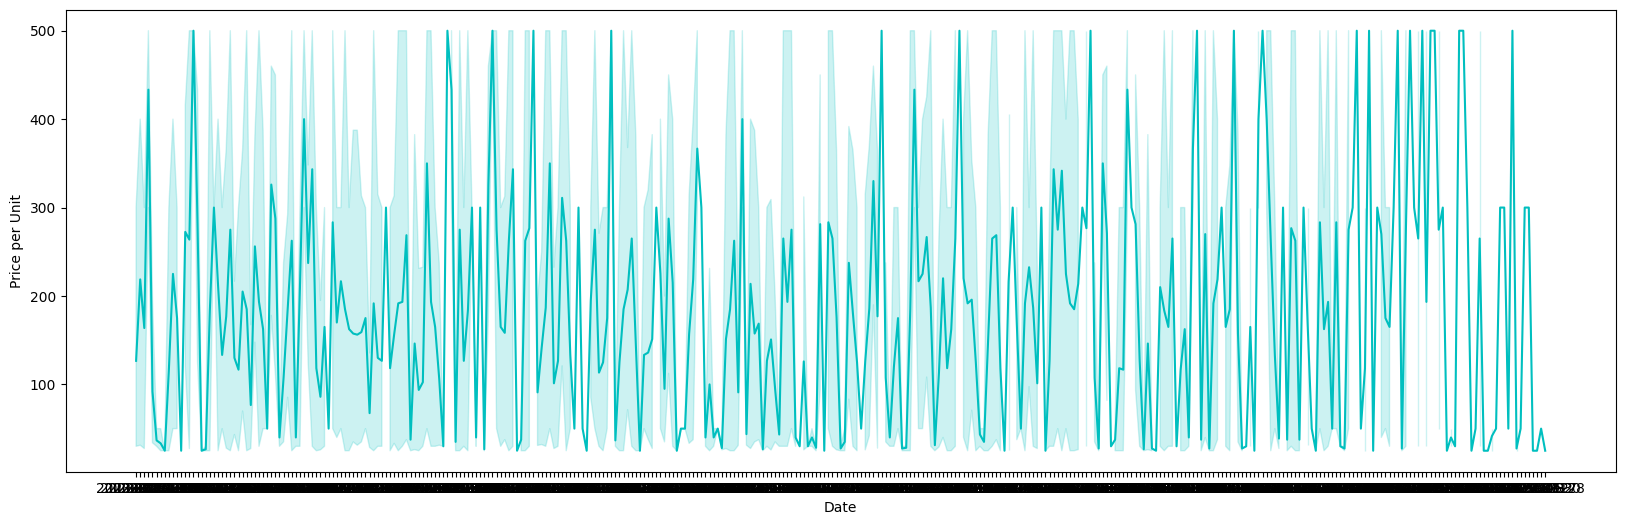

In [ ]:
plt.figure(figsize=(20,6))
sns.lineplot(data=df, x=df['Date'], y=df['Price per Unit'], color='c')
plt.show

In [ ]:
X=df.drop(['Date','Customer ID'],axis=1)
y=df['Total Amount']

#Split the dataset into train and test data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#numerical processing pipeline
numeric_processor=Pipeline(
    steps=[
        ("scaler",StandardScaler())
    ]
)

In [ ]:
#categorical processing
from sklearn.preprocessing import OneHotEncoder

categorical_processor=Pipeline(
    steps=[
        ("onehot",OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [ ]:
#combine technique
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(
    [
        ('categorical',categorical_processor,['Gender','Product Category']),
        ('numerical',numeric_processor,['Age','Quantity','Price per Unit','Total Amount'])
    ]
)

In [ ]:
from sklearn.pipeline import make_pipeline

pipe=make_pipeline(preprocessor,LinearRegression())

In [ ]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'Product Category']),
                                                 ('numerical',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Quantity',
                                                   'Price per Unit',
                                                   'Total Amount'])])),
                ('linearregression', LinearRegression())])

In [ ]:
from sklearn.metrics import r2_score
y_pred = pipe.predict(X_test)
score=r2_score(y_pred,y_test)

In [ ]:
print(score)

1.0


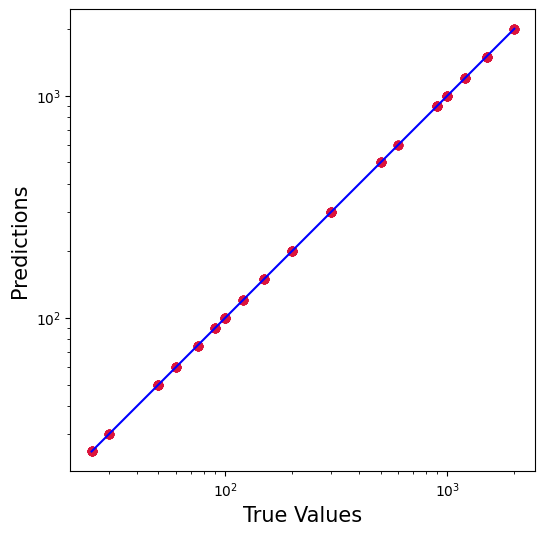

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(y_pred), max(y_test))
p2 = min(min(y_pred), min(y_test))

plt.plot([p1, p2], [p1, p2], 'b-')

plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()

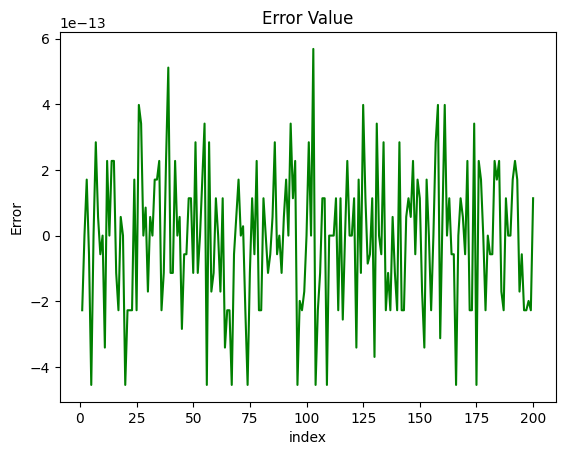

In [ ]:
# plotting the error
c = [i for i in range(1,len(y_test)+1,1)]
plt.plot(c,y_test-y_pred,color='green',linestyle='-')
plt.xlabel('index')
plt.ylabel('Error')
plt.title('Error Value')
plt.show()

**Numerical**

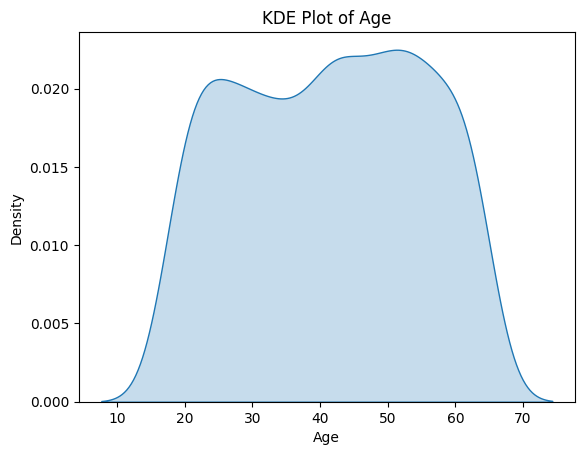

In [23]:
# KDE Plot - Age

sns.kdeplot(df['Age'], fill=True)

plt.title('KDE Plot of Age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

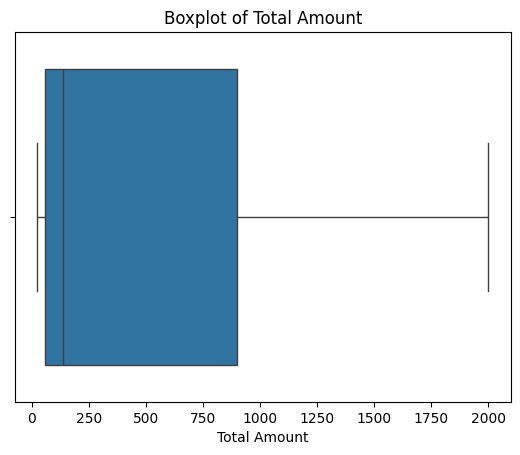

In [24]:
# Boxplot - Total Amount

sns.boxplot(x=df['Total Amount'])

plt.title('Boxplot of Total Amount')
plt.xlabel('Total Amount')
plt.show()

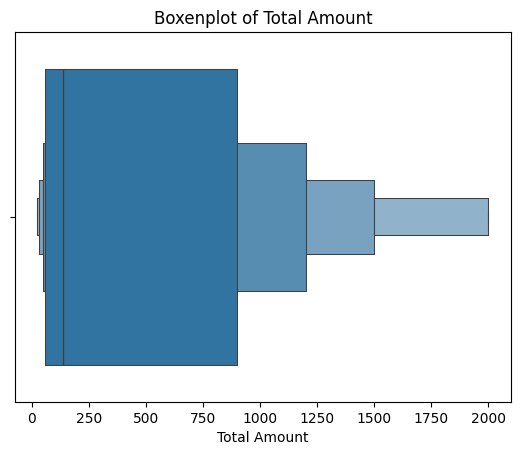

In [25]:
# Boxenplot - Total Amount

sns.boxenplot(x=df['Total Amount'])

plt.title('Boxenplot of Total Amount')
plt.xlabel('Total Amount')
plt.show()

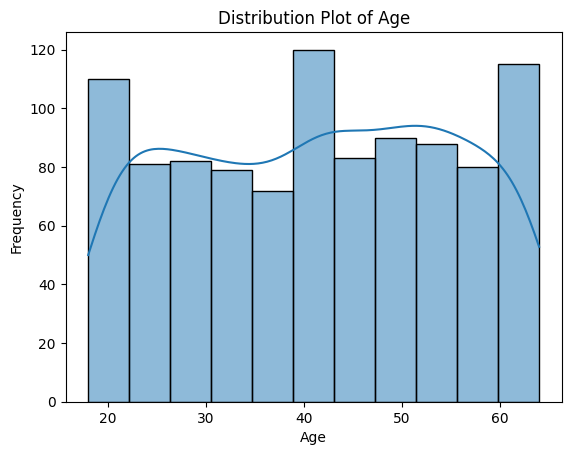

In [26]:
# Distplot - Age

sns.histplot(df['Age'], kde=True)

plt.title('Distribution Plot of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Bivariate analysis**

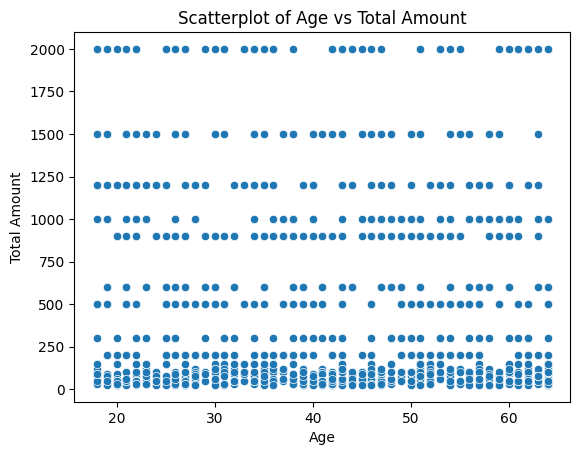

In [27]:
# Scatterplot - Age vs Total Amount

sns.scatterplot(
    x='Age',
    y='Total Amount',
    data=df
)

plt.title('Scatterplot of Age vs Total Amount')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.show()

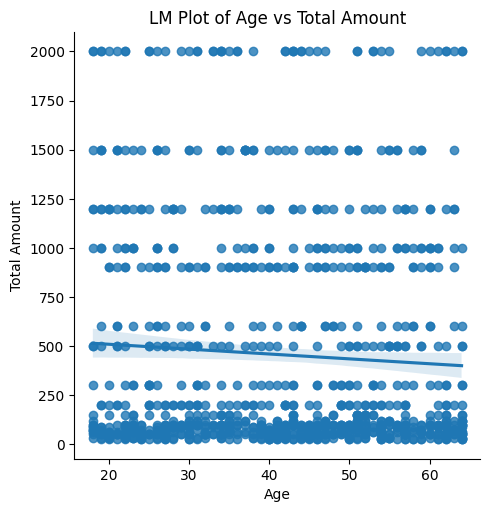

In [28]:
# LM Plot - Age vs Total Amount

sns.lmplot(
    x='Age',
    y='Total Amount',
    data=df
)

plt.title('LM Plot of Age vs Total Amount')
plt.show()

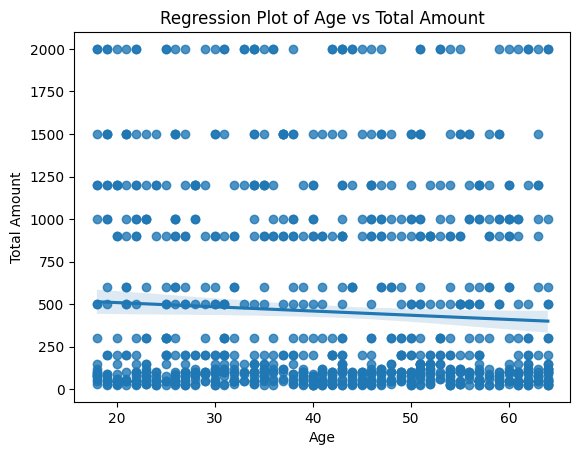

In [29]:
# Regression Plot - Age vs Total Amount

sns.regplot(
    x='Age',
    y='Total Amount',
    data=df
)

plt.title('Regression Plot of Age vs Total Amount')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.show()

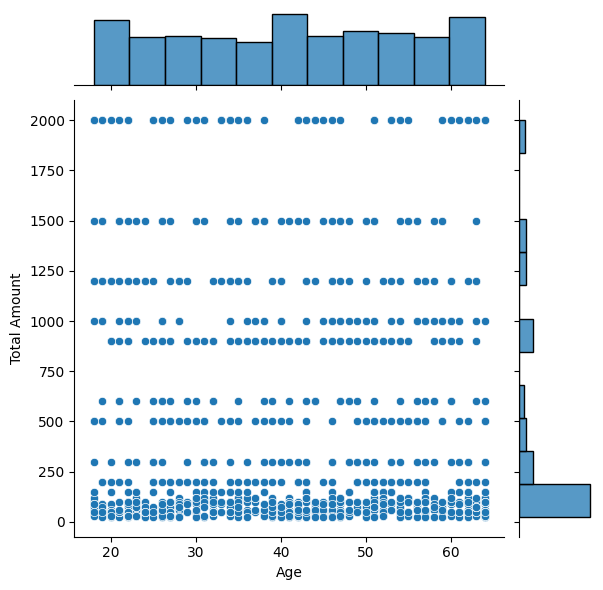

In [30]:
# Jointplot - Age vs Total Amount

sns.jointplot(
    x='Age',
    y='Total Amount',
    data=df
)

plt.show()

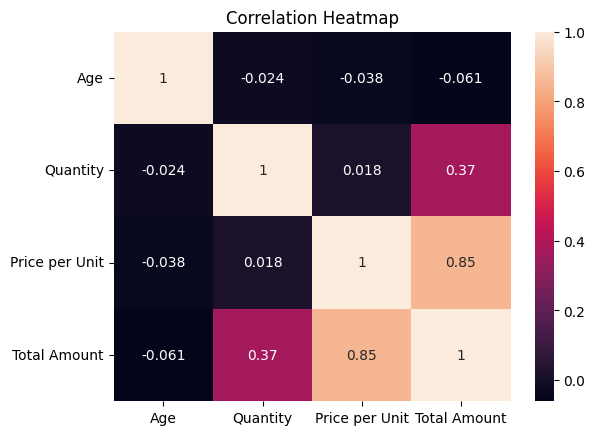

In [31]:
# Heatmap - Correlation

corr = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
].corr()

sns.heatmap(
    corr,
    annot=True
)

plt.title('Correlation Heatmap')
plt.show()

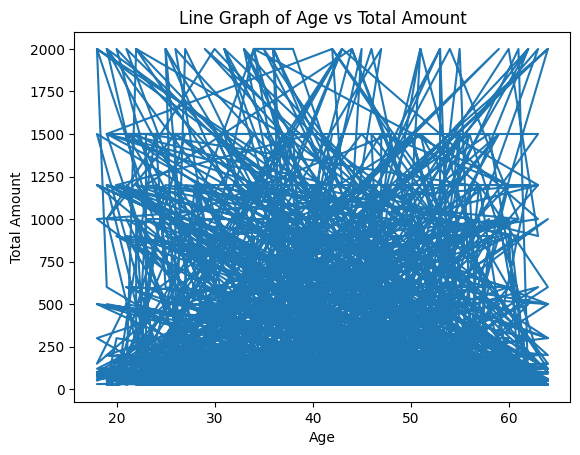

In [32]:
# Line Graph - Age vs Total Amount

plt.plot(
    df['Age'],
    df['Total Amount']
)

plt.title('Line Graph of Age vs Total Amount')
plt.xlabel('Age')
plt.ylabel('Total Amount')
plt.show()

**Numerical Categorical**

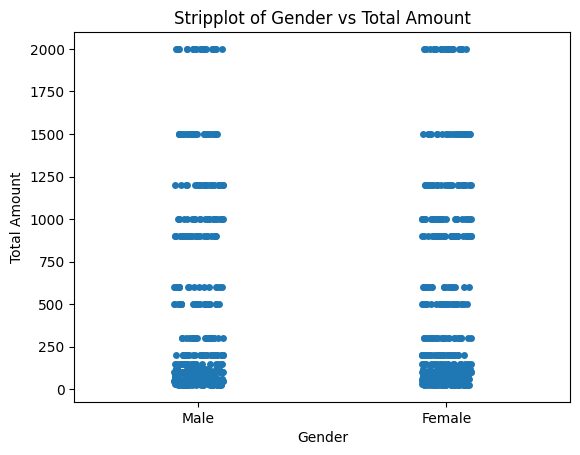

In [33]:
# Stripplot - Gender vs Total Amount

sns.stripplot(
    x='Gender',
    y='Total Amount',
    data=df
)

plt.title('Stripplot of Gender vs Total Amount')
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.show()

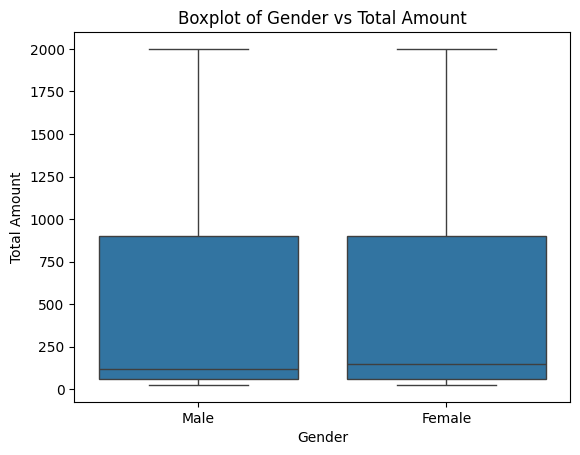

In [34]:
# Boxplot - Gender vs Total Amount

sns.boxplot(
    x='Gender',
    y='Total Amount',
    data=df
)

plt.title('Boxplot of Gender vs Total Amount')
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.show()

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning:

26.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning:

25.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning:

39.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning:

40.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



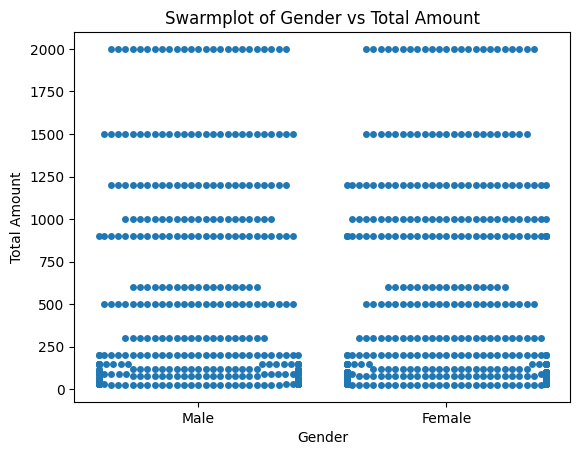

In [35]:
# Swarmplot - Gender vs Total Amount

sns.swarmplot(
    x='Gender',
    y='Total Amount',
    data=df
)

plt.title('Swarmplot of Gender vs Total Amount')
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.show()

**Categorical**

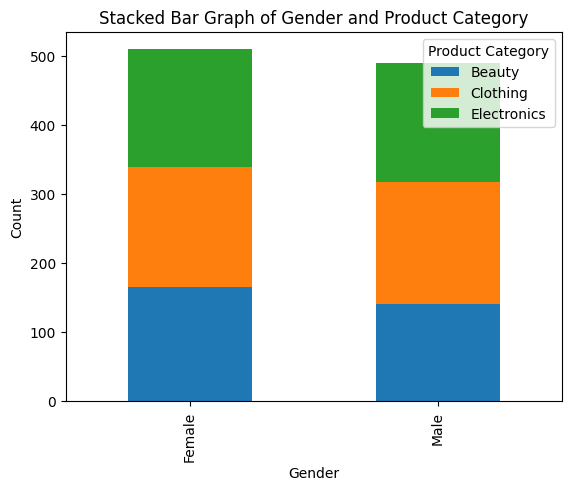

In [36]:
# Stacked Bar Graph - Gender vs Product Category

table = pd.crosstab(
    df['Gender'],
    df['Product Category']
)

table.plot(
    kind='bar',
    stacked=True
)

plt.title('Stacked Bar Graph of Gender and Product Category')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

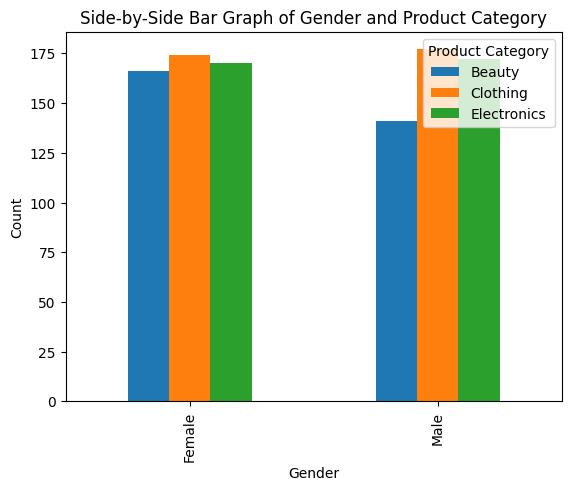

In [37]:
# Side-by-Side Bar Graph - Gender vs Product Category

table = pd.crosstab(
    df['Gender'],
    df['Product Category']
)

table.plot(kind='bar')

plt.title('Side-by-Side Bar Graph of Gender and Product Category')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()